In [1]:
!python --version

Python 3.12.12


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Parameters (Step 1 & 2)
- $S_0 = 100$
- $r = 5\%$
- $\sigma = 20\%$
- $T = 3$ months (0.25 years)

In [3]:
S0 = 100
r = 0.05
sigma = 0.20
T = 0.25
K = 100 #ATM

## Binomial Tree (CRR Model)
- $\Delta t = T / N$
- $u = e^{\sigma \sqrt{\Delta t}}$
- $d = 1/u = e^{-\sigma \sqrt{\Delta t}}$
- $p = \frac{e^{r \Delta t} - d}{u - d}$
- Stock price at node $(i, j)$: $S_{i,j} = S_0 u^j d^{i-j}$ for $i$ steps and $j$ up moves.
- Option value at maturity: $V_{N,j} = \max(S_{N,j} - K, 0)$ for call, $\max(K - S_{N,j}, 0)$ for put.
- Backward induction: $V_{i,j} = e^{-r \Delta t} [p V_{i+1, j+1} + (1-p) V_{i+1, j}]$
- American option: $V_{i,j} = \max(\text{Exercise Value}, e^{-r \Delta t} [p V_{i+1, j+1} + (1-p) V_{i+1, j}])$
- Delta at time 0: $\Delta = \frac{V_{1,1} - V_{1,0}}{S_{1,1} - S_{1,0}}$

# Common Functions

In [4]:
from enum import Enum, auto

class OptionType(Enum):
    CALL = auto()
    PUT = auto()

class OptionStyle(Enum):
    EUROPEAN = auto()
    AMERICAN = auto()

In [5]:
def binomial_tree(curr_p, strike, rate, v, t_tot, steps, option_type=OptionType.CALL, style=OptionStyle.EUROPEAN):
    # Setup step params
    h = t_tot / steps
    u = np.exp(v * np.sqrt(h))
    d = 1.0 / u
    q = (np.exp(rate * h) - d) / (u - d)
    df = np.exp(-rate * h)

    # Grid init
    stk = np.zeros((steps + 1, steps + 1))
    opt = np.zeros((steps + 1, steps + 1))
    side = 1 if option_type == OptionType.CALL else -1

    # Fill stock prices
    for i in range(steps + 1):
        for j in range(i + 1):
            stk[j, i] = curr_p * (u**(i - j)) * (d**j)

    # Maturity payoffs
    for j in range(steps + 1):
        pay = side * (stk[j, steps] - strike)
        opt[j, steps] = pay if pay > 0 else 0.0

    # Step backward
    for i in range(steps - 1, -1, -1):
        for j in range(i + 1):
            # risk neutral val
            ev = df * (q * opt[j, i + 1] + (1 - q) * opt[j + 1, i + 1])

            if style == OptionStyle.AMERICAN:
                val = side * (stk[j, i] - strike)
                opt[j, i] = ev if ev > val else val
            else:
                opt[j, i] = ev

    # Grab first step delta
    d1 = (opt[0, 1] - opt[1, 1]) / (stk[0, 1] - stk[1, 1])

    return opt[0, 0], d1

### **Member A tasks 5-7:**

In [6]:
# question 5 & 6
import time

steps = [25, 50, 100, 200, 500, 1000, 2000, 5000]

print(f"{'N':<6}"
      f"{'Call':<12}{'ΔCall':<12}{'dCall':<12}"
      f"{'Put':<12}{'ΔPut':<12}{'dPut':<12}"
      f"{'Time (s)':<12}")
print("-"*90)

prev_call = None
prev_put = None

for N in steps:

    start = time.perf_counter()

    call_price, call_delta = binomial_tree(
        S0, K, r, sigma, T, N,
        OptionType.CALL, OptionStyle.EUROPEAN
    )

    put_price, put_delta = binomial_tree(
        S0, K, r, sigma, T, N,
        OptionType.PUT, OptionStyle.EUROPEAN
    )

    end = time.perf_counter()
    elapsed = end - start

    # Change vs previous N
    if prev_call is None:
        d_call = 0.0
        d_put = 0.0
    else:
        d_call = call_price - prev_call
        d_put = put_price - prev_put

    print(f"{N:<6}"
          f"{call_price:<12.2f}{call_delta:<12.6f}{d_call:<12.6f}"
          f"{put_price:<12.2f}{put_delta:<12.6f}{d_put:<12.6f}"
          f"{elapsed:<12.6f}")

    # print(f"{N:<5} "
    #   f"{call_price:.2f} "
    #   f"{call_delta:.2f} "
    #   f"{put_price:.2f} "
    #   f"{d_put:.2f}")

    prev_call = call_price
    prev_put = put_price

N     Call        ΔCall       dCall       Put         ΔPut        dPut        Time (s)    
------------------------------------------------------------------------------------------
25    4.65        0.568171    0.000000    3.41        -0.431829   0.000000    0.002295    
50    4.60        0.569120    -0.058734   3.35        -0.430880   -0.058734   0.011427    
100   4.61        0.569290    0.009945    3.36        -0.430710   0.009945    0.035131    
200   4.61        0.569375    0.004982    3.37        -0.430625   0.004982    0.082206    
500   4.61        0.569426    0.002992    3.37        -0.430574   0.002992    0.977005    
1000  4.61        0.569443    0.000998    3.37        -0.430557   0.000998    8.324121    
2000  4.61        0.569452    0.000499    3.37        -0.430548   0.000499    8.002036    
5000  4.61        0.569457    0.000299    3.37        -0.430543   0.000299    47.746041   


**From the table above, I obtain the following observations:**

*+) Considering dCall/dPut:*

- The error decreases approximately at a rate proportional to 1/N

- After N = 500, the change becomes very small

- After N = 1000,  the change is almost negligible

*+) Considering ΔCall/ΔPut:*

- From N = 500 onward, the changes are also very small

*+) Considering computation time:*

- From N = 500 onward, execution time increases significantly, especially from 1000 - 2000

**Based on these observations, I select N = 500 for the binomial tree with the given data.**

Delta (Δ) measures the sensitivity of the option price to the underlying stock price. It shows how the option price changes if the stock price increases by 1 unit.

With N = 500:

- If the stock price increases, the call price also increases, so **ΔCall > 0**. From the table, it is approximately 0.569. This means that if the stock price increases by 1, the call price increases by about 0.569.

- In contrast, **ΔPut < 0 (opposite sign to ΔCall)**. From the table, it is approximately -0.431. This means that if the stock price increases by 1, the put price decreases by about 0.431.

If we consider the magnitude (ignoring the sign), **ΔCall is larger than ΔPut**.

In addition, we can observe that:

**ΔCall - ΔPut = 1**

since the European options do not pay dividends. This is a result of put-call parity.

In [7]:
# question 7
sigma_old = 0.20
sigma_new = 0.25
N = 500

# Prices at 20%
call_old, _ = binomial_tree(S0, K, r, sigma_old, T, N,
                            OptionType.CALL, OptionStyle.EUROPEAN)

put_old, _ = binomial_tree(S0, K, r, sigma_old, T, N,
                           OptionType.PUT, OptionStyle.EUROPEAN)

# Prices at 25%
call_new, _ = binomial_tree(S0, K, r, sigma_new, T, N,
                            OptionType.CALL, OptionStyle.EUROPEAN)

put_new, _ = binomial_tree(S0, K, r, sigma_new, T, N,
                           OptionType.PUT, OptionStyle.EUROPEAN)

# Change in price
delta_call_vol = call_new - call_old
delta_put_vol = put_new - put_old

# Approximate Vega
vega_call = delta_call_vol / (sigma_new - sigma_old)
vega_put = delta_put_vol / (sigma_new - sigma_old)

# Print table
print("Option    Price(20%)   Price(25%)   ΔV        Vega")
print("---------------------------------------------------------")
print(f"Call      {call_old:<12.2f}{call_new:<12.2f}"
      f"{delta_call_vol:<10.4f}{vega_call:.4f}")

print(f"Put       {put_old:<12.2f}{put_new:<12.2f}"
      f"{delta_put_vol:<10.4f}{vega_put:.4f}")

Option    Price(20%)   Price(25%)   ΔV        Vega
---------------------------------------------------------
Call      4.61        5.60        0.9829    19.6582
Put       3.37        4.35        0.9829    19.6582


When volatility increases from 20% to 25%, both the call and put prices increase by the same amount. Specifically:

ΔV(Call) = ΔV(Put) = 0.9829

Vega(Call) = Vega(Put) = 19.6528

**The positive value of Vega indicates that option prices increase when volatility increases.**

# American Calls/Put with Binomial Tree [8-10]

In [8]:
steps = [50,100,200,500, 1000]

call_prices = []
call_deltas = []
put_prices = []
put_deltas = []

print(f"{'N':<6}{'Call(Am)':<15}{'Delta(C)':<15}{'Put(Am)':<15}{'Delta(P)':<15}")
print("-"*70)
for N in steps:
    call_price, call_delta = binomial_tree(
        S0, K, r, sigma, T, N,
        OptionType.CALL, OptionStyle.AMERICAN)
    call_prices.append(call_price)
    call_deltas.append(call_delta)

    put_price, put_delta = binomial_tree(
        S0, K, r, sigma, T, N,
        OptionType.PUT, OptionStyle.AMERICAN)
    put_prices.append(put_price)
    put_deltas.append(put_delta)

    call_deltas
    print(f"{N:<6}"
          f"{call_price:<15.2f}{call_delta:<15.6f}{put_price:<15.2f}{put_delta:<15.6f}")


N     Call(Am)       Delta(C)       Put(Am)        Delta(P)       
----------------------------------------------------------------------
50    4.60           0.569120       3.47           -0.450262      
100   4.61           0.569290       3.47           -0.449831      
200   4.61           0.569375       3.48           -0.449623      
500   4.61           0.569426       3.48           -0.449500      
1000  4.61           0.569443       3.48           -0.449459      


## 8: American Option: No of steps & overall process:


*   As no of steps N increase 50 to 1000, both option price gradualize converge indicating stability.
*   American Call price stabilize at 4.614 and with Delta 0.5694 confirming no early exercise premium.
*   American Put converge to 3.479 with delta at -0.4495
*   Comparing step size , the change from = 500 to N= 1000 is neglibile
*   So N= 500 is recommended as it provide price stability upto 3 decimal and stable Greeks




# 9: American Option: Greek Delta for Amercian Call & Put at time 0

## American call & Put deltas compare

In [9]:
print(f"{'N':<6}{'Delta(C)':<15}{'Delta(P)':<15}")
print("-"*30)
for N_val, c_delta, p_delta in zip(steps, call_deltas, put_deltas):
  print(f"{N_val:<6}{c_delta:<15.6f}{p_delta:<15.6f}")

N     Delta(C)       Delta(P)       
------------------------------
50    0.569120       -0.450262      
100   0.569290       -0.449831      
200   0.569375       -0.449623      
500   0.569426       -0.449500      
1000  0.569443       -0.449459      


## Convergence


*   As N increase, both delta conver . Call to 0.56944 and Put to -0.44946

## Sign Comparison


*   Call delta is positive
*   Put delta is negative

## Magnitude Comparison


*   Call > Put --> Thus call more sensitive to stock price change than put

## Call delta Positive


*   Since payoff = max(S-K,0)
*   As stock price increase, call  value increase so Delta is positive.
*   Delta= 0.569 means if stock increase by 1 unit then call increse by 0.57 units

## Put Delta negative
*   Since payoff = max(K-S,0)
*   stock price incrse, Put decrease. Hence Delta is neg.
*   Delta put = -0.449 means if stock increase by 1 unit, put decrease by 0.45 units

## Not symmetry
*   Becuase American option Put has early exercise value, and hence parity is modifty and hence delta do not sum to 1










# 10.American Option: Sensitivities & Differential impact

In [10]:

sigma_new = 0.25
d_sigma = sigma_new - sigma

N = 500

# --- CALL ---
call_base, _ = binomial_tree(S0, K, r, sigma, T, N,OptionType.CALL, OptionStyle.AMERICAN)
call_new, _ = binomial_tree(S0, K, r, sigma_new, T, N,OptionType.CALL, OptionStyle.AMERICAN)


# --- PUT ---
put_base, _ = binomial_tree(S0, K, r, sigma, T, N,OptionType.PUT, OptionStyle.AMERICAN)
put_new, _ = binomial_tree(S0, K, r, sigma_new, T, N,OptionType.PUT, OptionStyle.AMERICAN)


In [11]:
call_vega = (call_new - call_base) / d_sigma
put_vega = (put_new - put_base) / d_sigma
print("\nVolatility Sensitivity (20% -> 25%)")
print("-" * 50)
print(f"Call Price (20%) : {call_base:.5f}")
print(f"Call Price (25%) : {call_new:.5f}")
print(f"Call Vega        : {call_vega:.5f}")
print()
print(f"Put Price (20%)  : {put_base:.5f}")
print(f"Put Price (25%)  : {put_new:.5f}")
print(f"Put Vega         : {put_vega:.5f}")


Volatility Sensitivity (20% -> 25%)
--------------------------------------------------
Call Price (20%) : 4.61300
Call Price (25%) : 5.59591
Call Vega        : 19.65823

Put Price (20%)  : 3.47883
Put Price (25%)  : 4.45856
Put Vega         : 19.59467


## Interpretation of result on American option due to change in volatility


*   CAll price incrase significantly. Inc. Prob. of extreme upward moves --> benefit call
*   Putl price incrase significantly. Inc. prob. of extreme downwar move --> benefit put.
*   $\frac{∂σ}{∂V}​>0$ for both options

## Differential impact between call & Put


*   Call Vege ~ 19.66 and Put Veg~ 19.60 . 1% increase in volatility increase option price by about 0.196
*   This is from put-call parity. Amercial call behave like Euro. call
*   Early exercise not optimal. Put has only small early exervise premium








## Member C [11-14]

**Question 11: Verification of Put–Call Parity for European Options**

Using the converged results at N = 500, we obtain:

    European Call price: 4.61

    European Put price: 3.37

$S_0 = 100$\
$K = 100$\
$r = 5\%$\
$T = 0.25 years$

For European options, the put-call parity states that:



$$C - P = S_0 - Ke^{-rT}$$


Step 1: Compute the right-hand side:

$$
\begin{aligned}
Ke^{-rT} &= 100 \cdot e^{-0.05 \times 0.25} \\
&= 100 \cdot e^{-0.0125} \\
&\approx 100 \cdot 0.987577 \\
&= 98.76
\end{aligned}
$$

Step 2: Compute the left-hand side:

$$C - P = 4.61 - 3.37 = 1.24$$

Both sides are equal and up to rounding.

$$C - P = S_0 - Ke^{-rT}$$


Therefore, put–call parity holds for the European options priced using the binomial tree.

This is expected because European options cannot be exercised early, and the binomial model enforces no-arbitrage conditions. If parity did not hold, an arbitrage opportunity would exist.




Question 12: Verification of Put–Call Parity for American Options

Using $N = 500$



*   American call price: 4.613
*   American put price: 3.479

Compute the left hand side, we have:

$$C_A - P_A = 4.613 - 3.479 = 1.134$$

When we compute the right hand side, we have:

$$S_0 - Ke^{-rT} = 1.24$$

Clearly,
$$1.134 \neq 1.24$$

Therefore, strict put–call parity does not hold for American options.

This occurs because American options allow early exercise. In particular, the American put contains an early exercise premium, while the American call (for a non-dividend-paying stock) does not benefit from early exercise. This asymmetry breaks the strict equality seen in European options.





Question 13. Comparison of European and American Call Prices

From the binomial tree results at $N = 500$



*   European Call = 4.61
*   American Call = 4.613

The difference is,

$$4.613 - 4.61 = 0.003$$

The difference is extremely small and can be attributed to numerical approximation.

For a non-dividend-paying stock, early exercise of a call is not optimal. Therefore, in theory:

$$C_A = C_E$$


The binomial results confirm this expectation.



Question 14: Comparison of European and American Put Prices

From the result at $N = 500$



*   European Call = 3.37
*   American Call = 3.479

$$3.479 - 3.37 = 0.109$$

The American put is approximately 11 cents more expensive.

This difference represents the early exercise premium embedded in the American put. If the option becomes sufficiently in-the-money, it may be optimal to exercise before maturity. This additional flexibility increases the value of the American put.

Therefore, in general:

$$P_A \geq P_E$$

This inequality will always hold. The magnitude of the difference depends on interest rates, volatility, time to maturity, and moneyness.

# Step 2

# European Options with Trinomial Tree [15-16]

## Trinomial Tree (Hull's Method)
- $\Delta t = T / N$
- $\Delta x = \sigma \sqrt{3 \Delta t}$
- $u = e^{\Delta x}$
- $d = e^{-\Delta x}$
- $m = 1$
- Risk-neutral probabilities:
  - $p_u = \frac{1}{2} \left[ \frac{\sigma^2 \Delta t + (r - \sigma^2/2)^2 \Delta t^2}{\Delta x^2} + \frac{(r - \sigma^2/2) \Delta t}{\Delta x} \right]$
  - $p_d = \frac{1}{2} \left[ \frac{\sigma^2 \Delta t + (r - \sigma^2/2)^2 \Delta t^2}{\Delta x^2} - \frac{(r - \sigma^2/2) \Delta t}{\Delta x} \right]$
  - $p_m = 1 - p_u - p_d$
- Stock price at node $(i, j)$: $S_{i,j} = S_0 e^{j \Delta x}$ (where $j$ is the number of up steps from the middle path)
- Option value: $V_{i,j} = e^{-r \Delta t} [p_u V_{i+1, j+1} + p_m V_{i+1, j} + p_d V_{i+1, j-1}]$


In [12]:
def trinomial_tree(S0, K, r, sigma, T, N, option_type=OptionType.CALL, style=OptionStyle.EUROPEAN):
    # setup basics
    h = T / N
    jump = sigma * np.sqrt(3.0 * h)

    # calc drift and weights - slightly messy but works
    mu = r - 0.5 * sigma**2
    var_term = (sigma**2 * h + (mu * h)**2) / jump**2
    drift_term = mu * h / jump

    w_u = 0.5 * (var_term + drift_term)
    w_d = 0.5 * (var_term - drift_term)
    w_m = 1.0 - w_u - w_d

    df = np.exp(-r * h)
    is_call = 1 if option_type == OptionType.CALL else -1

    # grid setup
    grid_size = 2 * N + 1
    prices = np.zeros((grid_size, N + 1))
    vals = np.zeros((grid_size, N + 1))

    # fill prices using offset logic
    for tick in range(N + 1):
        for level in range(N - tick, N + tick + 1):
            prices[level, tick] = S0 * np.exp((N - level) * jump)

    # terminal payoff
    final_px = prices[:, N]
    vals[:, N] = [max(0, is_call * (p - K)) for p in final_px]

    # work backwards
    for t in range(N - 1, -1, -1):
        for s in range(N - t, N + t + 1):
            # weighted average of future nodes
            expected = df * (w_u * vals[s - 1, t + 1] + w_m * vals[s, t + 1] + w_d * vals[s + 1, t + 1])

            if style == OptionStyle.AMERICAN:
                intrinsic = max(0, is_call * (prices[s, t] - K))
                vals[s, t] = expected if expected > intrinsic else intrinsic
            else:
                vals[s, t] = expected

    return vals[N, 0]

## 15. European Call options  Deep OTM, OTM, ATM, ITM,and Deep ITM.

In [13]:
moneyness_levels = [0.90, 0.95, 1.00, 1.05, 1.10]
classifications = ["Deep ITM", "ITM", "ATM", "OTM", "Deep OTM"]

print(f"{'Moneyness':<12} | {'Strike (K)':<12} | {'Classification':<15} | {'Call Price':<10}")
print("-" * 58)

for m, label in zip(moneyness_levels, classifications):
    k = S0 * m
    price = trinomial_tree(S0,k,r,sigma,T,N,OptionType.CALL,OptionStyle.EUROPEAN)
    print(f"{m:>11.0%} | {k:>12.2f} | {label:<15} | ${price:.2f}")

Moneyness    | Strike (K)   | Classification  | Call Price
----------------------------------------------------------
        90% |        90.00 | Deep ITM        | $11.67
        95% |        95.00 | ITM             | $7.72
       100% |       100.00 | ATM             | $4.61
       105% |       105.00 | OTM             | $2.48
       110% |       110.00 | Deep OTM        | $1.19


### Observation & Logic:


*   As Strike Price (K) increase , Call option price decrease
*   Higher price we have to pay to buy stock, less valuable option becomes .
*   Deep ITM calls have high intrinsic value while Deep OTM calls rely purely on time value






## 16. European Put options  Deep OTM, OTM, ATM, ITM,and Deep ITM.

In [14]:
print(f"{'Moneyness':<12} | {'Strike (K)':<12} | {'Classification':<15} | {'Put Price':<10}")
print("-" * 58)

for m, label in zip(moneyness_levels, classifications):
    k = S0 * m
    price = trinomial_tree(S0,k,r,sigma,T,N,OptionType.PUT,OptionStyle.EUROPEAN)
    print(f"{m:>11.0%} | {k:>12.2f} | {label:<15} | ${price:.2f}")

Moneyness    | Strike (K)   | Classification  | Put Price 
----------------------------------------------------------
        90% |        90.00 | Deep ITM        | $0.55
        95% |        95.00 | ITM             | $1.53
       100% |       100.00 | ATM             | $3.37
       105% |       105.00 | OTM             | $6.17
       110% |       110.00 | Deep OTM        | $9.83


### Observation & Logic:


*   As Strike Price (K) increase , Put option price increase
*   Higher price incrases the profit potential for right to sell underlying stock






### **Member A tasks 17-18:**

In [15]:
# question 17
print(f"{'Moneyness':<12} | {'Strike (K)':<12} | {'Classification':<15} | {'Call Price':<10}")
print("-" * 58)

for m, label in zip(moneyness_levels, classifications):
    k = S0 * m
    price = trinomial_tree(S0,k,r,sigma,T,N,OptionType.CALL,OptionStyle.AMERICAN)
    print(f"{m:>11.0%} | {k:>12.2f} | {label:<15} | ${price:.2f}")

Moneyness    | Strike (K)   | Classification  | Call Price
----------------------------------------------------------
        90% |        90.00 | Deep ITM        | $11.67
        95% |        95.00 | ITM             | $7.72
       100% |       100.00 | ATM             | $4.61
       105% |       105.00 | OTM             | $2.48
       110% |       110.00 | Deep OTM        | $1.19


From the table, it is clear that the Call Price decreases as the Strike (K) increases.

This is also consistent with financial theory:

- When K is low (Deep ITM), the Intrinsic Value (a component of the Option Value) is large, so the Call Price is high

- As K increases, the probability that the option finishes ITM decreases

- A Deep OTM option consists almost entirely of Time Value, so the Call Price is low

In this case, since there is no dividend, the American Call ~ European Call.

In [16]:
# question 18
print(f"{'Moneyness':<12} | {'Strike (K)':<12} | {'Classification':<15} | {'Put Price':<10}")
print("-" * 58)

for m, label in zip(moneyness_levels, classifications):
    k = S0 * m
    price = trinomial_tree(S0,k,r,sigma,T,N,OptionType.PUT,OptionStyle.AMERICAN)
    print(f"{m:>11.0%} | {k:>12.2f} | {label:<15} | ${price:.2f}")

Moneyness    | Strike (K)   | Classification  | Put Price 
----------------------------------------------------------
        90% |        90.00 | Deep ITM        | $0.56
        95% |        95.00 | ITM             | $1.57
       100% |       100.00 | ATM             | $3.48
       105% |       105.00 | OTM             | $6.42
       110% |       110.00 | Deep OTM        | $10.33


# Member C [19-24]

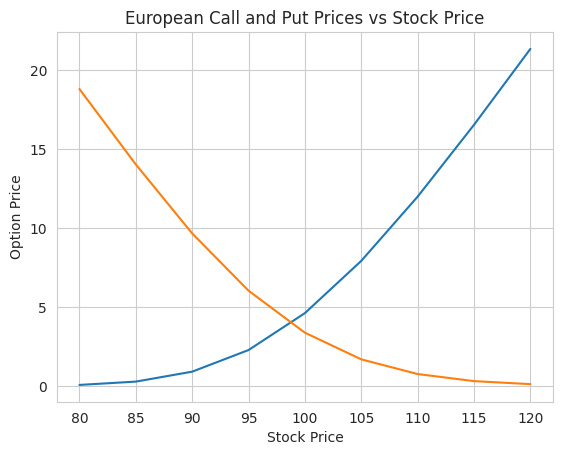

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r = 0.05
sigma = 0.20
T = 0.25
K = 100
N = 500

stock_prices = np.arange(80, 121, 5)

euro_calls = []
euro_puts = []

for S in stock_prices:
    call_price, _ = binomial_tree(
        S, K, r, sigma, T, N,
        OptionType.CALL, OptionStyle.EUROPEAN)

    put_price, _ = binomial_tree(
        S, K, r, sigma, T, N,
        OptionType.PUT, OptionStyle.EUROPEAN)

    euro_calls.append(round(call_price, 2))
    euro_puts.append(round(put_price, 2))

plt.figure()
plt.plot(stock_prices, euro_calls)
plt.plot(stock_prices, euro_puts)

plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.title("European Call and Put Prices vs Stock Price")
plt.show()

**Question 19: European Option Prices vs Stock Price**

The graph above shows the relationship between European option prices and the underlying stock price.

As the stock price increases:

The European call price increases.

The European put price decreases.

This behavior is consistent with financial theory. A call option gives the right to buy the asset at the strike price. Therefore, as the stock price increases, the likelihood of finishing in-the-money increases, which raises the call’s value.

Conversely, a put option gives the right to sell at the strike price. As the stock price increases, the probability of finishing in-the-money decreases, causing the put value to decline.

The curves are convex, reflecting the non-linear payoff structure of options. This convexity is consistent with the positive gamma property of options.

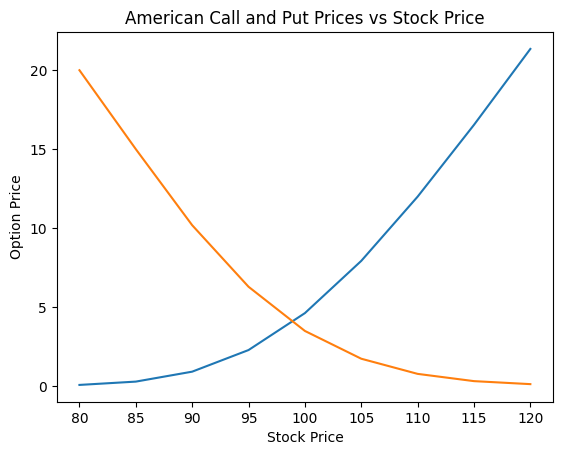

In [18]:
import numpy as np
import matplotlib.pyplot as plt

american_calls = []
american_puts = []

for S in stock_prices:
    call_price, _ = binomial_tree(
        S, K, r, sigma, T, N,
        OptionType.CALL, OptionStyle.AMERICAN)

    put_price, _ = binomial_tree(
        S, K, r, sigma, T, N,
        OptionType.PUT, OptionStyle.AMERICAN)

    american_calls.append(round(call_price, 2))
    american_puts.append(round(put_price, 2))

plt.figure()
plt.plot(stock_prices, american_calls)
plt.plot(stock_prices, american_puts)

plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.title("American Call and Put Prices vs Stock Price")
plt.show()

**Question 20: American Option Prices vs Stock Price**

The graph for American options above follows a similar pattern to the European case:

The American call price increases as the stock price increases.

The American put price decreases as the stock price increases.

For a non-dividend-paying stock, the American call price is nearly identical to the European call price. This confirms that early exercise is not optimal for calls in this setting.

However, the American put price is consistently higher than the European put price. This difference reflects the early exercise premium embedded in the American put. When the option is sufficiently in-the-money, early exercise may be optimal, increasing its value relative to the European put.

Overall, the graphical behavior confirms theoretical expectations and supports the numerical findings from earlier sections.

**Question 21: European and American Call Prices vs Strike**

Using the five selected strike prices:

| Strike | European Call | American Call |
|--------|---------------|---------------|
| 90     | 11.67         | 11.67         |
| 95     | 7.72          | 7.72          |
| 100    | 4.61          | 4.61          |
| 105    | 2.48          | 2.48          |
| 110    | 1.19          | 1.19          |

As the strike price increases, both European and American call prices decrease.

This behavior is expected. A higher strike makes it less likely that the call finishes in-the-money. Therefore, the option becomes less valuable as strike increases.

An important observation is that the American and European call prices are identical across all strikes. This confirms that early exercise is not optimal for calls on a non-dividend-paying stock.

As a result:

$$C_A = C_E$$

This result is consistent with option pricing theory.



In [39]:
american_calls,euro_calls,stock_prices

([np.float64(0.06),
  np.float64(0.27),
  np.float64(0.9),
  np.float64(2.27),
  np.float64(4.61),
  np.float64(7.92),
  np.float64(11.99),
  np.float64(16.54),
  np.float64(21.35)],
 [np.float64(0.06),
  np.float64(0.27),
  np.float64(0.9),
  np.float64(2.27),
  np.float64(4.61),
  np.float64(7.92),
  np.float64(11.99),
  np.float64(16.54),
  np.float64(21.35)],
 array([ 80,  85,  90,  95, 100, 105, 110, 115, 120]))

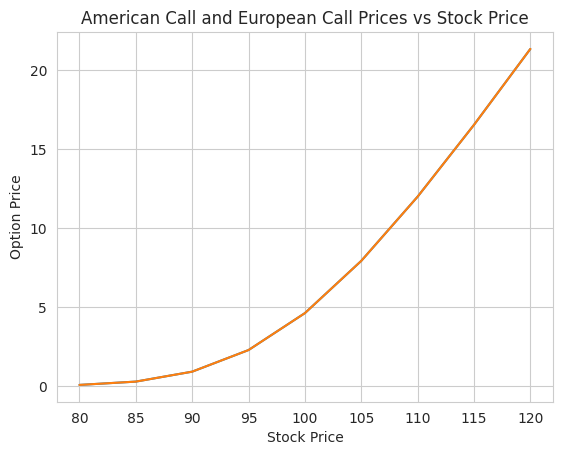

In [40]:
plt.figure()
plt.plot(stock_prices, american_calls)
plt.plot(stock_prices, euro_calls)

plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.title("American Call and European Call Prices vs Stock Price")
plt.show()

**Question 22: European and American Put Prices vs Strike**

Using the same strike values:

| Strike | European Put | American Put |
|--------|--------------|--------------|
| 90     | 0.55         | 0.56         |
| 95     | 1.53         | 1.57         |
| 100    | 3.37         | 3.48         |
| 105    | 6.17         | 6.42         |
| 110    | 9.83         | 10.33        |

Unlike calls, put prices increase as the strike price increases.

A higher strike increases the probability that the put finishes in-the-money, which increases its value.

Another important observation is that American puts are consistently more expensive than European puts. This difference reflects the early exercise premium embedded in the American put. Since early exercise may be optimal when the put is sufficiently in-the-money, the American version carries additional value.

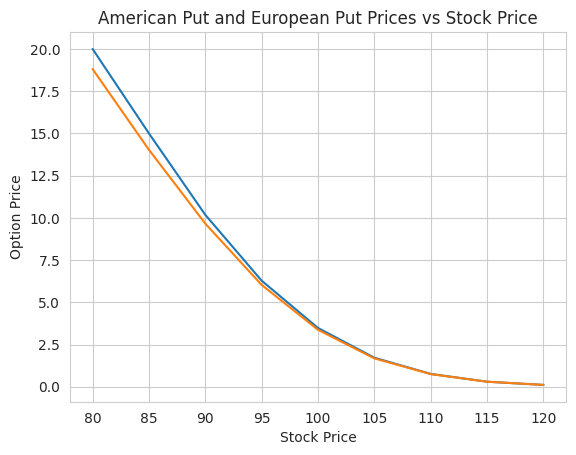

In [41]:
plt.figure()
plt.plot(stock_prices, american_puts)
plt.plot(stock_prices, euro_puts)

plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.title("American Put and European Put Prices vs Stock Price")
plt.show()

**Question 23. Put–Call Parity Check (European Options)**

For European options, put–call parity is:

$$C - P = S_0 - Ke^{-rT}$$

Where:

$$S_0 = 100$$

$$r = 5\%$$

$$T = 0.25$$

First compute the discount factor:

$$e^{-rT} = e^{-0.05 \times 0.25} = e^{-0.0125} \approx 0.987577$$

Thus:

$$Ke^{-rT} = K \times 0.987577$$

Now verify put-call parity $C - P = S_0 - Ke^{-rT}$ for each strike:



**At Strike = 90**

$$C - P = 11.67 - 0.55 = 11.12$$

$$S_0 - Ke^{-rT} = 100 - (90 \times 0.987577) = 100 - 88.88 = 11.12$$

Parity holds.


**At Strike = 95**

$$C - P = 7.72 - 1.53 = 6.19$$

$$S_0 - Ke^{-rT} = 100 - (95 \times 0.987577) = 100 - 93.82 = 6.18$$

Holds within rounding.


**At Strike = 100**

$$C - P = 4.61 - 3.37 = 1.24$$

$$S_0 - Ke^{-rT} = 100 - 98.76 = 1.24$$
 Holds exactly.


**At Strike = 105**

$$C - P = 2.48 - 6.17 = -3.69$$

$$S_0 - Ke^{-rT} = 100 - 103.70 = -3.70$$

Holds within rounding.


**At Strike = 110**

$$C - P = 1.19 - 9.83 = -8.64$$

$$S_0 - Ke^{-rT} = 100 - 108.63 = -8.63$$

Holds within rounding.

From our calculations, we observed that Put–call parity holds for all five European strikes. The small differences observed are due to rounding. This confirms that the trinomial model satisfies no-arbitrage conditions.

**Question 24: Put–Call Parity Check (American Options)**

For American options, strict put–call parity does not necessarily hold due to early exercise.

Where:

$$S_0 = 100$$

$$r = 5\%$$

$$T = 0.25$$

$$e^{-rT} = e^{-0.05 \times 0.25} = e^{-0.0125} \approx 0.987577$$

$$Ke^{-rT} = K \times 0.987577$$



**At Strike = 90**

Left side: $C_A - P_A = 11.67 - 0.56 = 11.11$

Right side: $S_0 - Ke^{-rT} = 100 - 88.88 = 11.12$

$$11.11 \neq 11.12$$

It was close, but not exact.


**At Strike = 95**

Left side: $C_A - P_A = 7.72 - 1.57 = 6.15$

Right side: $S_0 - Ke^{-rT} = 100 - 93.82 = 6.18$

$$6.15 \neq 6.18$$

Not equal.


**At Strike = 100**

Left side: $C_A - P_A = 4.61 - 3.48 = 1.13$

Right side: $S_0 - Ke^{-rT} = 100 - 98.76 = 1.24$

$$1.13 \neq 1.24$$

The difference reflects early exercise premium.


**At Strike = 105**

Left side: $C_A - P_A = 2.48 - 6.42 = -3.94$

Right side: $S_0 - Ke^{-rT} = 100 - 103.70 = -3.70$

$$-3.94 \neq -3.70$$

Not equal.


**At Strike = 110**

Left side: $C_A - P_A = 1.19 - 10.33 = -9.14$

Right side: $S_0 - Ke^{-rT} = 100 - 108.63 = -8.63$

$$-9.14 \neq -8.63$$

Not equal.

We observed that Put-call parity does not hold for American options due to the early exercise premium embedded in American put prices.

# Step 3

## Parameters (Step 3)
- $S_0 = 180$
- $r = 2\%$
- $\sigma = 25\%$
- $T = 6$ months (0.5 years)
- $N = 3$ steps binomial tree

In [19]:
S0_25 = 180
r_25 = 0.02
sigma_25 = 0.25
T_25 = 0.5
K_25 = 182
N_25 = 3

In [20]:
def binomial_tree_detailed(start_px, strike, rate, vol, time, steps, optionType=OptionType.PUT, style=OptionStyle.EUROPEAN):
    # Setup constants
    gap = time / steps
    up = np.exp(vol * np.sqrt(gap))
    down = 1 / up
    prob = (np.exp(rate * gap) - down) / (up - down)
    re_dis = np.exp(-rate * gap)

    # Grid init
    px_tree = np.zeros((steps + 1, steps + 1))
    val_tree = np.zeros((steps + 1, steps + 1))
    is_call = 1 if optionType == OptionType.CALL else -1

    # Populate price grid
    for col in range(steps + 1):
        for row in range(col + 1):
            px_tree[row, col] = start_px * (up**(col - row)) * (down**row)

    # Final payoffs
    val_tree[:, steps] = [max(0, is_call * (x - strike)) for x in px_tree[:, steps]]

    # Step back
    for col in range(steps - 1, -1, -1):
        for row in range(col + 1):
            future_val = re_dis * (prob * val_tree[row, col + 1] + (1 - prob) * val_tree[row + 1, col + 1])
            if style == OptionStyle.AMERICAN:
                val_tree[row, col] = max(future_val, is_call * (px_tree[row, col] - strike))
            else:
                val_tree[row, col] = future_val

    # Delta calc
    d_map = np.zeros((steps, steps))
    for c in range(steps):
        for r in range(c + 1):
            # manual delta slope
            d_map[r, c] = (val_tree[r, c + 1] - val_tree[r + 1, c + 1]) / (px_tree[r, c + 1] - px_tree[r + 1, c + 1])

    return px_tree, val_tree, d_map, prob, up, down, gap

# 25. Dynamic Delta Hedging : European Put Option

In [21]:
S_mat, V_mat, D_mat, p_val, u_val, d_val,_ = binomial_tree_detailed(S0_25, K_25, r_25, sigma_25, T_25, N_25,OptionType.PUT, OptionStyle.EUROPEAN)
print("\n Binomial Tree (3 Steps) For European Put Option:")
print("Stock Prices:\n", S_mat.round(2))
print("Option Values:\n", V_mat.round(2))
print("Deltas:\n", D_mat.round(4))
print(f"p: {p_val:.4f}, u: {u_val:.4f}, d: {d_val:.4f}")


 Binomial Tree (3 Steps) For European Put Option:
Stock Prices:
 [[180.   199.34 220.76 244.48]
 [  0.   162.54 180.   199.34]
 [  0.     0.   146.77 162.54]
 [  0.     0.     0.   132.52]]
Option Values:
 [[13.82  5.01  0.    0.  ]
 [ 0.   22.41  9.88  0.  ]
 [ 0.    0.   34.63 19.46]
 [ 0.    0.    0.   49.48]]
Deltas:
 [[-0.4726 -0.2423  0.    ]
 [ 0.     -0.7447 -0.5288]
 [ 0.      0.     -1.    ]]
p: 0.4908, u: 1.1075, d: 0.9030


# 26. Dynmaic Delta Hedging : American Put Option

In [22]:
N_amer= 25
s_amer,c_amer,deltas_amer,p_amer,u_amer,d_amer,dt_amer=binomial_tree_detailed(S0_25, K_25, r_25, sigma_25, T_25, N_amer, OptionType.PUT, OptionStyle.AMERICAN)

In [23]:
print(f"\nAmerican Put (25 steps): {c_amer[0,0]:.2f}")
print(f"\nAmerican Delta (25 steps): {deltas_amer[0,0]:.5f}")


American Put (25 steps): 13.04

American Delta (25 steps): -0.47556


## Evolution of cash account through chosen step (all up & up)

In [24]:
# choosing all up path
path_indices = [0]*(N_amer + 1)

# cashflow
cash_acc,shares_held = np.zeros(N_amer + 1), np.zeros(N_amer + 1)
# steps_evolution_pd= pd.DataFrame(columns=["Step","Stock Price","Put Value","Delta","Cash Account"])
evolution_rows = []
#step_0
shares_held[0] = deltas_amer[0,0]
cash_acc[0] = c_amer[0,0] - shares_held[0]*s_amer[0,0] # cash account is option price - stock value
# steps_evolution_pd = steps_evolution_pd.append({"Step": 0, "Stock Price": s_amer[0,0], "Put Value": c_amer[0,0], "Delta": deltas_amer[0,0], "Cash Account": cash_acc[0]}, ignore_index=True)
evolution_rows.append({"Step": 0, "Stock Price": s_amer[0,0], "Put Value": c_amer[0,0], "Delta": deltas_amer[0,0], "Cash Account": cash_acc[0]})
for i in range(1,N_amer+1):
    j = path_indices[i]
    pre_j = path_indices[i-1]
    # interest calculation
    cash_acc[i] = cash_acc[i-1] * np.exp(r_25 * dt_amer)
    if i< N_amer:
        shares_held[i] = deltas_amer[j,i]
        delta_change = shares_held[i] - shares_held[i-1]
        cash_acc[i] -= delta_change * s_amer[j,i] # buy/sell stock to rebalance
    else: #payoff
        cash_acc[i] += shares_held[i-1] * s_amer[j,i]
        cash_acc[i] -= max(0, K_25 - s_amer[j,i])
        shares_held[i] = 0
    if i< N_amer:
        print(f"Step {i}: Stock={s_amer[j,i]:.2f}, Put Value={c_amer[j,i]:.2f}, Delta={deltas_amer[j,i]:.4f}, Cash={cash_acc[i]:.2f}")
        evolution_rows.append({"Step": i, "Stock Price": s_amer[j,i], "Put Value": c_amer[j,i], "Delta": deltas_amer[j,i], "Cash Account": cash_acc[i]})
    else:
        print(f"Step {i}: Stock={s_amer[j,i]:.2f}, Put Value={c_amer[j,i]:.2f}, Delta={0:.4f}, Cash={cash_acc[i]:.2f}")
        evolution_rows.append({"Step": i, "Stock Price": s_amer[j,i], "Put Value": c_amer[j,i], "Delta": 0, "Cash Account": cash_acc[i]})

evolution_pd = pd.DataFrame(evolution_rows)

Step 1: Stock=186.48, Put Value=9.99, Delta=-0.3951, Cash=83.67
Step 2: Stock=193.19, Put Value=7.38, Delta=-0.3163, Cash=68.48
Step 3: Stock=200.14, Put Value=5.20, Delta=-0.2423, Cash=53.69
Step 4: Stock=207.34, Put Value=3.48, Delta=-0.1760, Cash=39.98
Step 5: Stock=214.81, Put Value=2.18, Delta=-0.1200, Cash=27.97
Step 6: Stock=222.54, Put Value=1.27, Delta=-0.0758, Cash=18.13
Step 7: Stock=230.54, Put Value=0.67, Delta=-0.0435, Cash=10.69
Step 8: Stock=238.84, Put Value=0.31, Delta=-0.0221, Cash=5.59
Step 9: Stock=247.44, Put Value=0.12, Delta=-0.0096, Cash=2.49
Step 10: Stock=256.34, Put Value=0.04, Delta=-0.0033, Cash=0.89
Step 11: Stock=265.57, Put Value=0.01, Delta=-0.0008, Cash=0.23
Step 12: Stock=275.12, Put Value=0.00, Delta=-0.0001, Cash=0.03
Step 13: Stock=285.02, Put Value=0.00, Delta=0.0000, Cash=0.00
Step 14: Stock=295.28, Put Value=0.00, Delta=0.0000, Cash=0.00
Step 15: Stock=305.91, Put Value=0.00, Delta=0.0000, Cash=0.00
Step 16: Stock=316.92, Put Value=0.00, Delta=

In [25]:
evolution_pd['Stock Price'] = evolution_pd['Stock Price'].astype(float).round(2)
evolution_pd['Put Value'] = evolution_pd['Put Value'].astype(float).round(2)
evolution_pd['Delta'] = evolution_pd['Delta'].astype(float).round(4)
evolution_pd['Cash Account'] = evolution_pd['Cash Account'].astype(float).round(2)

In [26]:
display(evolution_pd)

,Step,Stock Price,Put Value,Delta,Cash Account
0,0,180.00,13.04,-0.4756,98.64
1,1,186.48,9.99,-0.3951,83.67
2,2,193.19,7.38,-0.3163,68.48
3,3,200.14,5.20,-0.2423,53.69
4,4,207.34,3.48,-0.1760,39.98
5,5,214.81,2.18,-0.1200,27.97
6,6,222.54,1.27,-0.0758,18.13
7,7,230.54,0.67,-0.0435,10.69
8,8,238.84,0.31,-0.0221,5.59
9,9,247.44,0.12,-0.0096,2.49


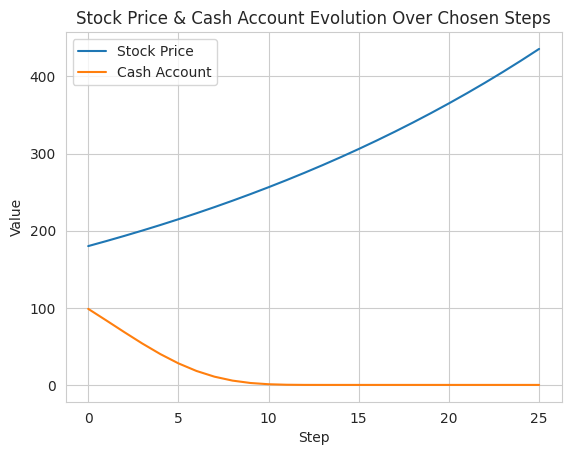

In [27]:
# visualtion Stock Price & Cash Account
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure()
sns.set_style("whitegrid")
sns.lineplot(data=evolution_pd, x="Step", y="Stock Price", label="Stock Price ")
sns.lineplot(data=evolution_pd, x="Step", y="Cash Account", label="Cash Account")
plt.title("Stock Price & Cash Account Evolution Over Chosen Steps")
plt.ylabel("Value")
plt.show()

# 27. Asian ATM Put option

In [28]:
def asian_option_mc(S_ini, K, T, r, sigma, N, M, optionType):
    dt = T / N  # Define time step
    u = np.exp(sigma * np.sqrt(dt))  # Define u
    d = np.exp(-sigma * np.sqrt(dt))  # Define d
    p = (np.exp(r * dt) - d) / (u - d)  # risk neutral probs
    epsilon = 0.01 * S_ini
    S_ini_plus = S_ini + epsilon # for delta we use finite difference
    random_moves = np.random.binomial(1, p, (M, N))

    S_paths = np.zeros((M, N + 1))
    S_paths[:, 0] = S_ini
    S_paths_plus = np.zeros((M, N + 1))
    S_paths_plus[:, 0] = S_ini_plus
    for i in range(1, N + 1):
        moves = np.where(random_moves[:, i-1] == 1, u, d) # random moves , 1 is up 0 is down
        S_paths[:, i] = S_paths[:, i - 1] * moves
        S_paths_plus[:, i] = S_paths_plus[:, i - 1] * moves
    averages =np.mean(S_paths, axis=1)
    averages_plus=np.mean(S_paths_plus, axis=1)
    if optionType == OptionType.CALL:
        payoff=np.maximum(averages - K, 0)
        payoff_plus=np.maximum(averages_plus - K, 0)
    else:
        payoff=np.maximum(K - averages, 0)
        payoff_plus=np.maximum(K - averages_plus, 0)

    #discounting back to T0
    df = np.exp(-r * T)
    price = df * np.mean(payoff)
    price_plus = df * np.mean(payoff_plus)
    delta = (price_plus - price) / (epsilon)

    return S_paths, payoff, delta

In [29]:
S0_27 = 180
r_27 = 0.02
sigma_27 = 0.25
T_27 = 0.5 # 6 months
K_27 = 180 #ATM
N_27 = 25
M_27 = 10000


In [30]:
M_values = np.arange(1000, M_27+1, 1000)

prices = []
deltas = []

print(f"{'M':>6} | {'Price':>10} | {'Delta':>10}")
print("-" * 32)

for M in M_values:
    _, payoffs, delta = asian_option_mc(S0_27, K_27, T_27, r_27, sigma_27, N_27, M, OptionType.PUT)
    price = np.mean(payoffs)
    prices.append(price)
    deltas.append(delta)
    print(f"{M:6d} | {price:10.2f} | {delta:10.4f}")

     M |      Price |      Delta
--------------------------------
  1000 |       6.69 |    -0.4487
  2000 |       6.94 |    -0.4338
  3000 |       6.90 |    -0.4438
  4000 |       6.83 |    -0.4434
  5000 |       6.94 |    -0.4452
  6000 |       6.93 |    -0.4415
  7000 |       6.80 |    -0.4455
  8000 |       6.76 |    -0.4415
  9000 |       6.94 |    -0.4449
 10000 |       6.85 |    -0.4400


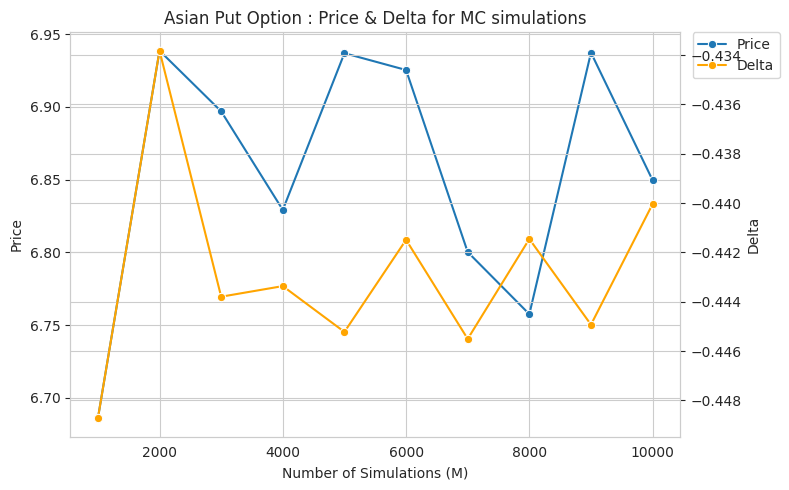

In [31]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.lineplot(x=M_values, y=prices, marker="o", ax=ax1, label="Price", legend=False)
ax1.set_xlabel("Number of Simulations (M)")
ax1.set_ylabel("Price")

ax2 = ax1.twinx()
sns.lineplot(x=M_values, y=deltas, marker="o", ax=ax2, label="Delta", color="orange", legend=False)
ax2.set_ylabel("Delta")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
handles, labels = h1 + h2, l1 + l2
ax1.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.0, ncol=1)

plt.title("Asian Put Option : Price & Delta for MC simulations")
plt.tight_layout()
plt.show()

## Asian Put option Evolution of cash account through chosen step (all up & up)

In [32]:
def get_asian_put_price_delta_simulation(S_curr,curr_sum,step,K,T,r,sigma,N,MC_sim):
  dt=T/N
  t_rem=T-step*dt
  if t_rem<=0:
    return max(K - (curr_sum / (N + 1)), 0), 0
  def _price(S_start):
    steps_left=N-step
    z = np.random.standard_normal((MC_sim, steps_left)) #MC for remaining steps
    drift = (r - 0.5 * sigma**2) * dt # a term
    vol = sigma * np.sqrt(dt) #b terms

    g = np.exp(np.cumsum(drift + vol * z, axis=1))
    future_paths = S_start * g

    full_sums = curr_sum + np.sum(future_paths, axis=1)
    payoffs = np.maximum(K - (full_sums / (N + 1)), 0)
    return np.exp(-r * t_rem) * np.mean(payoffs)
  eps = S_curr*0.01
  p1 = _price(S_curr)
  p2 = _price(S_curr + eps)
  delta = (p2 - p1) / eps
  return p1,delta

In [33]:
S0_27 = 180
r_27 = 0.02
sigma_27 = 0.25
T_27 = 0.5 # 6 months
K_27 = 180 #ATM
N_27 = 25
M_27 = 10000
dt = T_27 / N_27
u=np.exp(sigma_27 * np.sqrt(dt))


In [34]:
# Initial Setup
initial_price, initial_delta = get_asian_put_price_delta_simulation(S0_27, S0_27, 0, K_27, T_27, r_27, sigma_27, N_27, M_27)
cash = [initial_price - (initial_delta * S0)]
deltas = [initial_delta]
running_sum = S0_27
path = [S0_27 * (u**i) for i in range(N_27 + 1)]
#  Loop for hedge
for i in range(1, N_27 + 1):
    running_sum += path[i]
    _, new_delta = get_asian_put_price_delta_simulation(path[i], running_sum,i,  K_27, T_27, r_27, sigma_27, N_27, 5000)

    trade_cost = (new_delta - deltas[-1]) * path[i]
    current_cash = cash[-1] * np.exp(r * dt) - trade_cost
    deltas.append(new_delta)
    cash.append(current_cash)

# Results
df_results = pd.DataFrame({
    'Step': np.arange(N_27 + 1),
    'Stock_Price': path,
    'Delta': deltas,
    'Cash_Account': cash
})

print(df_results.round(4))

avg_price = sum(path) / (N + 1)
final_payoff = max(K - avg_price, 0)
final_pnl = cash[-1] + (deltas[-1] * path[-1]) - final_payoff
print(f"\nFinal Average Price: {avg_price:.2f}")
print(f"Final Payoff: {final_payoff:.2f}")
print(f"Final Portfolio P&L: {final_pnl:.4f}")

    Step  Stock_Price   Delta  Cash_Account
0      0     180.0000 -0.4677       53.4372
1      1     186.4778 -0.2557       13.9610
2      2     193.1887 -0.1696       -2.6699
3      3     200.1412 -0.0678      -23.0471
4      4     207.3438 -0.0312      -30.6492
5      5     214.8056 -0.0075      -35.7761
6      6     222.5360 -0.0040      -36.5867
7      7     230.5446  0.0000      -37.5436
8      8     238.8414  0.0000      -37.5811
9      9     247.4367  0.0000      -37.6187
10    10     256.3414  0.0000      -37.6564
11    11     265.5666  0.0000      -37.6940
12    12     275.1237  0.0000      -37.7318
13    13     285.0248  0.0000      -37.7695
14    14     295.2822  0.0000      -37.8073
15    15     305.9088  0.0000      -37.8451
16    16     316.9177  0.0000      -37.8830
17    17     328.3229  0.0000      -37.9209
18    18     340.1385  0.0000      -37.9588
19    19     352.3793  0.0000      -37.9968
20    20     365.0607  0.0000      -38.0348
21    21     378.1984  0.0000   